# Grid-point regression: South-Pole-referenced growth rate on backward-differenced drivers

This notebook fits one independent linear regression at each spatial grid point:

$$
\text{growth\_rate}(t,r)-\text{growth\_rate}_{SPO}(t)
=
\beta_0(r)
+
\beta_E(r)\Delta E(t,r)
+
\beta_B(r)\Delta B(t,r)
+
\varepsilon(t,r).
$$

This version does **not** use the stored variables:

$$
\texttt{delta\_emission},\qquad \texttt{delta\_gosif}.
$$

Instead, it computes year-to-year changes directly from the raw variables using a **backward difference**:

$$
\Delta E(t,r)=E(t,r)-E(t-1,r),
$$

$$
\Delta B(t,r)=B(t,r)-B(t-1,r),
$$

where:

$$
E(t,r)=\texttt{emission}(t,r),
\qquad
B(t,r)=\texttt{gosif}(t,r).
$$

This is the natural convention if the target `growth_rate(t)` is interpreted as:

$$
\texttt{growth\_rate}(t,r)\approx CO_2(t,r)-CO_2(t-1,r).
$$

Because this is a backward difference, the first year is lost.  
For example, with 2015--2024 data, the regression uses retained time labels 2016--2024.

The notebook also keeps the previous corrections:

1. The regression is only solved where the full 3-component model is identifiable:
   
   $[\beta_0,\beta_E,\beta_B],$
   meaning the local design matrix must have rank 3.

2. The map plotting function draws land, ocean, coastlines, and country borders under/around the heatmaps when Cartopy is available.

## 1. Install required packages

```bash
pip install xarray netCDF4 numpy pandas matplotlib
```
Optional, for coastlines/borders: `pip install cartopy` (the notebook runs fine without it).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAS_CARTOPY = True
except Exception:
    HAS_CARTOPY = False

print("Cartopy available:", HAS_CARTOPY)

Cartopy available: False


## 2. Configuration

In [ ]:
INPUT_FILE = Path("../Input/unified_annual_carbon_dataset_2015_2024.nc")

OUTPUT_DIR = Path("../Output")
FIGURE_DIR = Path("../Figures_and_maps")
OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

OUTPUT_NC  = OUTPUT_DIR / "gridpoint_regression_spo_backward_delta_fullrank.nc"
OUTPUT_CSV = OUTPUT_DIR / "gridpoint_regression_spo_backward_delta_fullrank_flat.csv"

TARGET_VAR   = "growth_rate"  # referenced to the South Pole below
EMISSION_VAR = "emission"     # raw emission field; we manually compute emission(t)-emission(t-1)
BIO_VAR      = "gosif"        # raw GOSIF/SIF field; we manually compute gosif(t)-gosif(t-1)

# South Pole reference: zonal+meridional mean of growth_rate over the southernmost rows.
# SPO_LAT_MAX = -85 averages the southernmost 1-degree rows for stability.
SPO_LAT_MAX = -85.0

# Difference convention:
#   "backward" computes X(t)-X(t-1), labels the result by time t, and loses the first year.
DIFF_MODE = "backward"

# Predictors are NOT standardized by default.
# If True, manually computed delta_emission and delta_gosif are z-scored independently at each grid point.
STANDARDIZE = False

# Missing SIF is ocean/desert/ice, not zero -- do NOT fill it by default.
# Flip to True only if you specifically want missing drivers treated as 0 before differencing.
FILL_MISSING_DRIVERS_WITH_ZERO = False

# Strict fitting controls.
# REQUIRE_ALL_YEARS=True means a grid cell is fitted only if target, manual delta_emission,
# and manual delta_gosif are finite for every retained year in the time axis.
# With backward differences and 2015--2024 data, this means all 9 retained years.
# If this is too strict and solves too few cells, set it to False and use MIN_OBS.
REQUIRE_ALL_YEARS = True

# REQUIRE_FULL_RANK=True means the local design matrix [1, manual delta_emission, manual delta_gosif]
# must have rank 3, so the full beta0, beta_E, beta_B model is identifiable.
REQUIRE_FULL_RANK = True

# Used only if REQUIRE_ALL_YEARS=False.
MIN_OBS = 6

# Below this determinant threshold, X'X is considered numerically singular.
DET_TOL = 1e-30

print("Input :", INPUT_FILE.resolve())
print("Output:", OUTPUT_NC.resolve())

Input : D:\2026\Complexity72h\unified_annual_carbon_dataset_2015_2024.nc
Output: D:\2026\Complexity72h\outputs\gridpoint_regression_spo_backward_delta_fullrank.nc


## 3. Open the dataset

In [3]:
ds = xr.open_dataset(INPUT_FILE)
for v in ds.data_vars:
    print(f"- {v}: {ds[v].dims} {ds[v].shape}")
ds

- growth_rate: ('time', 'lat', 'lon') (10, 180, 360)
- emission: ('time', 'lat', 'lon') (10, 180, 360)
- gosif: ('time', 'lat', 'lon') (10, 180, 360)
- delta_emission: ('time', 'lat', 'lon') (10, 180, 360)
- delta_gosif: ('time', 'lat', 'lon') (10, 180, 360)
- cams_xco2: ('time', 'latitude', 'longitude') (10, 180, 360)
- growth_err: ('time', 'lat', 'lon') (10, 180, 360)
- mean_co2: ('time', 'lat', 'lon') (10, 180, 360)


<xarray.Dataset> Size: 29MB
Dimensions:         (time: 10, lat: 180, lon: 360, latitude: 180, longitude: 360)
Coordinates:
  * time            (time) int64 80B 2015 2016 2017 2018 ... 2021 2022 2023 2024
  * lat             (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * lon             (lon) float64 3kB -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
  * latitude        (latitude) float64 1kB -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
  * longitude       (longitude) float64 3kB -179.5 -178.5 -177.5 ... 178.5 179.5
Data variables:
    growth_rate     (time, lat, lon) float64 5MB ...
    emission        (time, lat, lon) float32 3MB ...
    gosif           (time, lat, lon) float32 3MB ...
    delta_emission  (time, lat, lon) float32 3MB ...
    delta_gosif     (time, lat, lon) float32 3MB ...
    cams_xco2       (time, latitude, longitude) float32 3MB ...
    growth_err      (time, lat, lon) float64 5MB ...
    mean_co2        (time, lat, lon) float64 5MB ...
Attributes:
    description:  Unified annual carbon dataset on growth-rate grid. Contains...

## 4. Build the South-Pole-referenced target and manually differenced predictors

The South Pole reference is one value per year:

$$
\texttt{growth\_rate}_{\mathrm{SPO}}(t)=
\big\langle
\texttt{growth\_rate}(t,\text{lat}\le\text{SPO\_LAT\_MAX},\text{lon})
\big\rangle.
$$

We subtract it from every grid cell to get:

$$
Y(t,r)=\texttt{growth\_rate}(t,r)-\texttt{growth\_rate}_{SPO}(t).
$$

Then we compute the driver changes manually from the raw fields:

$$
\Delta E(t,r)=\texttt{emission}(t,r)-\texttt{emission}(t-1,r),
$$

$$
\Delta B(t,r)=\texttt{gosif}(t,r)-\texttt{gosif}(t-1,r).
$$

Because this is a backward difference, the first year is dropped.  
So, with 2015--2024 raw data, the regression uses the retained time labels 2016--2024.

In [4]:
gr_full = ds[TARGET_VAR].transpose("time", "lat", "lon")
E_full = ds[EMISSION_VAR].transpose("time", "lat", "lon")
B_full = ds[BIO_VAR].transpose("time", "lat", "lon")

if FILL_MISSING_DRIVERS_WITH_ZERO:
    E_full = E_full.fillna(0)
    B_full = B_full.fillna(0)

if DIFF_MODE != "backward":
    raise ValueError("This notebook is written for DIFF_MODE='backward': X(t)-X(t-1), losing the first year.")

# Backward difference:
#   dX(t) = X(t) - X(t-1)
# The result is labelled by the later year t, so the first year is dropped.
retained_time = E_full["time"].isel(time=slice(1, None))

dE = xr.DataArray(
    E_full.isel(time=slice(1, None)).values - E_full.isel(time=slice(0, -1)).values,
    coords={
        "time": retained_time.values,
        "lat": E_full["lat"].values,
        "lon": E_full["lon"].values,
    },
    dims=("time", "lat", "lon"),
    name="manual_delta_emission_backward",
    attrs={
        "description": "Backward difference computed from raw emission: emission(t)-emission(t-1), labelled by t",
        "source_variable": EMISSION_VAR,
    },
)

dB = xr.DataArray(
    B_full.isel(time=slice(1, None)).values - B_full.isel(time=slice(0, -1)).values,
    coords={
        "time": retained_time.values,
        "lat": B_full["lat"].values,
        "lon": B_full["lon"].values,
    },
    dims=("time", "lat", "lon"),
    name="manual_delta_gosif_backward",
    attrs={
        "description": "Backward difference computed from raw gosif: gosif(t)-gosif(t-1), labelled by t",
        "source_variable": BIO_VAR,
    },
)

# Align growth_rate to the retained time axis.
# With backward differencing, this drops the first target year too.
gr = gr_full.sel(time=retained_time)

# South Pole reference: zonal+meridional mean over southernmost rows, per retained year.
spo = gr.sel(lat=slice(-90, SPO_LAT_MAX)).mean(["lat", "lon"])

print("South Pole reference growth rate for retained years (ppm/yr):")
for yr, val in zip(gr["time"].values, spo.values):
    print(f"  {int(yr)}: {val:.3f}")

# SPO-referenced target anomaly.
y_anom = gr - spo
y_anom.name = "growth_rate_minus_spo"

print("\nTime axis:")
print("  original years :", ds['time'].values)
print("  retained years :", y_anom['time'].values)
print("  number retained:", y_anom.sizes["time"])

print("\nFraction finite:")
print("  target anomaly        :", float(np.isfinite(y_anom).mean()))
print("  manual delta_emission :", float(np.isfinite(dE).mean()))
print("  manual delta_gosif    :", float(np.isfinite(dB).mean()))

South Pole reference growth rate for retained years (ppm/yr):
  2016: 2.853
  2017: 2.080
  2018: 2.442
  2019: 2.372
  2020: 2.477
  2021: 2.152
  2022: 2.339
  2023: 2.088
  2024: 3.096

Time axis:
  original years : [2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]
  retained years : [2016 2017 2018 2019 2020 2021 2022 2023 2024]
  number retained: 9

Fraction finite:
  target anomaly        : 1.0
  manual delta_emission : 0.819122085048011
  manual delta_gosif    : 0.2754783950617284


## 5. Vectorized per-cell OLS

For every grid cell we fit:

$$
y = X\beta+\varepsilon,
\qquad
X=[1,\Delta E,\Delta B].
$$

Here:

$$
\Delta E(t,r)=\texttt{emission}(t,r)-\texttt{emission}(t-1,r),
$$

$$
\Delta B(t,r)=\texttt{gosif}(t,r)-\texttt{gosif}(t-1,r).
$$

The stricter correction is here:

- if `REQUIRE_ALL_YEARS = True`, a grid cell is fitted only when all retained years have finite target, manual `delta_emission`, and manual `delta_gosif`;
- if `REQUIRE_FULL_RANK = True`, a grid cell is fitted only when the local design matrix has rank 3.

So the model is not allowed to silently become an intercept-only or one-predictor regression.

In [5]:
def fit_all_grid_points(
    Y,
    P1,
    P2,
    min_obs=MIN_OBS,
    det_tol=DET_TOL,
    standardize=STANDARDIZE,
    require_all_years=REQUIRE_ALL_YEARS,
    require_full_rank=REQUIRE_FULL_RANK,
):
    """
    Vectorized OLS of Y on [1, P1, P2] over the time axis, per grid cell.

    Model:
        Y(t,r) = beta0(r) + beta_E(r)*P1(t,r) + beta_B(r)*P2(t,r)

    Strict fitting rules:
      - if require_all_years=True, all time points must be finite for Y, P1, and P2;
      - if require_full_rank=True, the local design matrix must have rank 3.

    Y, P1, P2 have shape (T, nlat, nlon).
    Returns dict of (nlat, nlon) maps.
    """

    T, nlat, nlon = Y.shape
    nc = nlat * nlon

    Yf = Y.reshape(T, nc).astype("float64")
    A1 = P1.reshape(T, nc).astype("float64")
    A2 = P2.reshape(T, nc).astype("float64")

    if standardize:
        def z(a):
            mu = np.nanmean(a, axis=0)
            sd = np.nanstd(a, axis=0)
            return (a - mu) / np.where(sd > 0, sd, np.nan)

        A1 = z(A1)
        A2 = z(A2)

    # A year is valid only if target and both predictors are finite.
    valid = np.isfinite(Yf) & np.isfinite(A1) & np.isfinite(A2)
    nvalid = valid.sum(axis=0)

    ones = np.ones_like(Yf)

    # Full design matrix: intercept + delta_emission + delta_gosif.
    X = np.stack([ones, A1, A2], axis=2)  # shape: (T, nc, 3)

    # Mask invalid years to zero so that they do not contribute to X'X or X'y.
    Xm = np.where(valid[..., None], X, 0.0)
    Ym = np.where(valid, Yf, 0.0)

    XtX = np.einsum("tni,tnj->nij", Xm, Xm)  # shape: (nc, 3, 3)
    Xty = np.einsum("tni,tn->ni", Xm, Ym)    # shape: (nc, 3)

    beta = np.full((nc, 3), np.nan)
    r2 = np.full(nc, np.nan)
    rmse = np.full(nc, np.nan)
    rank = np.zeros(nc, dtype=np.int16)
    det = np.full(nc, np.nan)

    # Observation condition.
    if require_all_years:
        enough = nvalid == T
    else:
        enough = nvalid >= min_obs

    idx_enough = np.where(enough)[0]

    if idx_enough.size:
        rank[idx_enough] = np.linalg.matrix_rank(XtX[idx_enough])
        det[idx_enough] = np.linalg.det(XtX[idx_enough])

    if require_full_rank:
        full_rank = rank == 3
    else:
        full_rank = np.ones(nc, dtype=bool)

    ok = enough & full_rank & np.isfinite(det) & (np.abs(det) > det_tol)
    idx = np.where(ok)[0]

    if idx.size:
        bsol = np.linalg.solve(XtX[idx], Xty[idx][..., None])[..., 0]
        beta[idx] = bsol

        Xs = Xm[:, idx, :]
        Ys = Ym[:, idx]
        Vs = valid[:, idx]

        fitted = np.einsum("tni,ni->tn", Xs, bsol)
        resid = np.where(Vs, Ys - fitted, 0.0)

        ss_res = (resid ** 2).sum(axis=0)

        nv = Vs.sum(axis=0)
        ybar = Ys.sum(axis=0) / np.maximum(nv, 1)
        ss_tot = (np.where(Vs, Ys - ybar, 0.0) ** 2).sum(axis=0)

        r2[idx] = 1.0 - ss_res / np.where(ss_tot > 0, ss_tot, np.nan)
        rmse[idx] = np.sqrt(ss_res / np.maximum(nv, 1))

    g = lambda a: a.reshape(nlat, nlon)

    return {
        "beta0": g(beta[:, 0]),
        "beta_E": g(beta[:, 1]),
        "beta_B": g(beta[:, 2]),
        "r2": g(r2),
        "rmse": g(rmse),
        "n_obs": g(nvalid.astype("int16")),
        "rank": g(rank.astype("int16")),
        "full_model_used": g(ok.astype("int16")),
    }

## 6. Fit every grid cell

In [6]:
res = fit_all_grid_points(
    y_anom.values,
    dE.values,
    dB.values,
    require_all_years=REQUIRE_ALL_YEARS,
    require_full_rank=REQUIRE_FULL_RANK,
)

n_total = res["beta_E"].size
n_solved = int(np.isfinite(res["beta_E"]).sum())
n_rank3 = int((res["rank"] == 3).sum())
n_full_used = int((res["full_model_used"] == 1).sum())

print(f"retained time points: {y_anom.sizes['time']}")
print(f"rank-3 cells        : {n_rank3} / {n_total}")
print(f"full-model solved   : {n_full_used} / {n_total}")
print(f"finite beta_E       : {n_solved} / {n_total}")

if n_solved > 0:
    print(f"median R^2   : {np.nanmedian(res['r2']):.3f}")
    print(f"median RMSE  : {np.nanmedian(res['rmse']):.3f} ppm/yr")
    print(f"median beta0 : {np.nanmedian(res['beta0']):+.3e}")
    print(f"median beta_E: {np.nanmedian(res['beta_E']):+.3e}")
    print(f"median beta_B: {np.nanmedian(res['beta_B']):+.3e}")
else:
    print("No cells were solved. If this is too strict, set REQUIRE_ALL_YEARS = False in the configuration cell.")

retained time points: 9
rank-3 cells        : 17512 / 64800
full-model solved   : 17512 / 64800
finite beta_E       : 17512 / 64800
median R^2   : 0.211
median RMSE  : 0.265 ppm/yr
median beta0 : +9.869e-02
median beta_E: +1.183e-05
median beta_B: -3.533e+00


## 7. Build and save the output dataset

In [7]:
lat = ds["lat"].values
lon = ds["lon"].values

out = xr.Dataset(
    data_vars={
        "beta0":  (("lat", "lon"), res["beta0"]),
        "beta_E": (("lat", "lon"), res["beta_E"]),
        "beta_B": (("lat", "lon"), res["beta_B"]),
        "r2":     (("lat", "lon"), res["r2"]),
        "rmse":   (("lat", "lon"), res["rmse"]),
        "n_obs":  (("lat", "lon"), res["n_obs"]),
        "rank":   (("lat", "lon"), res["rank"]),
        "full_model_used": (("lat", "lon"), res["full_model_used"]),
    },
    coords={"lat": lat, "lon": lon},
    attrs={
        "model": "growth_rate - SPO ~ beta0 + beta_E*(emission(t)-emission(t-1)) + beta_B*(gosif(t)-gosif(t-1))",
        "difference_mode": "backward",
        "retained_time_start": str(y_anom["time"].values[0]),
        "retained_time_end": str(y_anom["time"].values[-1]),
        "n_retained_time_points": int(y_anom.sizes["time"]),
        "spo_lat_max": SPO_LAT_MAX,
        "standardized_predictors": str(STANDARDIZE),
        "fill_missing_drivers_with_zero_before_differencing": str(FILL_MISSING_DRIVERS_WITH_ZERO),
        "require_all_years": str(REQUIRE_ALL_YEARS),
        "require_full_rank": str(REQUIRE_FULL_RANK),
        "min_obs_if_not_require_all_years": MIN_OBS,
    },
)

out["beta0"].attrs["description"] = "Intercept of the full local regression."
out["beta_E"].attrs["description"] = "Coefficient multiplying manually computed emission(t)-emission(t-1)."
out["beta_B"].attrs["description"] = "Coefficient multiplying manually computed gosif(t)-gosif(t-1)."
out["r2"].attrs["description"] = "In-sample R squared of the full local regression."
out["rmse"].attrs["description"] = "In-sample RMSE of the full local regression."
out["n_obs"].attrs["description"] = "Number of retained years where target, manual delta_emission, and manual delta_gosif are all finite."
out["rank"].attrs["description"] = "Rank of the local design matrix [1, manual delta_emission, manual delta_gosif]."
out["full_model_used"].attrs["description"] = "1 where the strict full 3-component model was fitted, 0 otherwise."

enc = {v: {"zlib": True, "complevel": 4} for v in out.data_vars}
out.to_netcdf(OUTPUT_NC, encoding=enc)
print("saved:", OUTPUT_NC)

flat = out.to_dataframe().reset_index()
flat.to_csv(OUTPUT_CSV, index=False)
print("saved:", OUTPUT_CSV)
flat.head()

saved: outputs\gridpoint_regression_spo_backward_delta_fullrank.nc
saved: outputs\gridpoint_regression_spo_backward_delta_fullrank_flat.csv


,lat,lon,beta0,beta_E,beta_B,r2,rmse,n_obs,rank,full_model_used
0,-89.5,-179.5,NaN,NaN,NaN,NaN,NaN,0,0,0
1,-89.5,-178.5,NaN,NaN,NaN,NaN,NaN,0,0,0
2,-89.5,-177.5,NaN,NaN,NaN,NaN,NaN,0,0,0
3,-89.5,-176.5,NaN,NaN,NaN,NaN,NaN,0,0,0
4,-89.5,-175.5,NaN,NaN,NaN,NaN,NaN,0,0,0


## 8. Map plotting helper

In [10]:
def plot_map(
    da,
    title=None,
    cmap="coolwarm",
    robust=True,
    save_path=None,
    alpha=0.88,
    show_land=True,
    show_borders=True,
):
    """
    Plot a lat-lon heatmap with land/ocean/country regions underneath.

    If Cartopy is available:
      - ocean and land are drawn below the heatmap;
      - coastlines and country borders are drawn on top;
      - the heatmap is semi-transparent through alpha.

    If Cartopy is not available:
      - a simple xarray lat-lon plot is used.
    """

    title = title or da.name

    if HAS_CARTOPY:
        fig = plt.figure(figsize=(13, 6))
        ax = plt.axes(projection=ccrs.PlateCarree())

        # Background below the heatmap.
        if show_land:
            ax.add_feature(
                cfeature.OCEAN,
                facecolor="white",
                edgecolor="none",
                zorder=0,
            )
            ax.add_feature(
                cfeature.LAND,
                facecolor="lightgray",
                edgecolor="none",
                zorder=0,
            )

        # Heatmap.
        da.plot(
            ax=ax,
            x="lon",
            y="lat",
            transform=ccrs.PlateCarree(),
            cmap=cmap,
            robust=robust,
            alpha=alpha,
            zorder=2,
            cbar_kwargs={"label": da.name},
        )

        # Geographic outlines.
        ax.coastlines(linewidth=0.8, zorder=3)

        if show_borders:
            ax.add_feature(
                cfeature.BORDERS,
                linewidth=0.4,
                edgecolor="black",
                zorder=3,
            )

        ax.set_global()
        ax.set_title(title)

    else:
        plt.figure(figsize=(12, 5))
        da.plot(
            x="lon",
            y="lat",
            cmap=cmap,
            robust=robust,
            alpha=alpha,
            cbar_kwargs={"label": da.name},
        )
        plt.title(title)
        plt.xlabel("Longitude")
        plt.ylabel("Latitude")

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=160, bbox_inches="tight")

    plt.show()

## 9. Coefficient maps

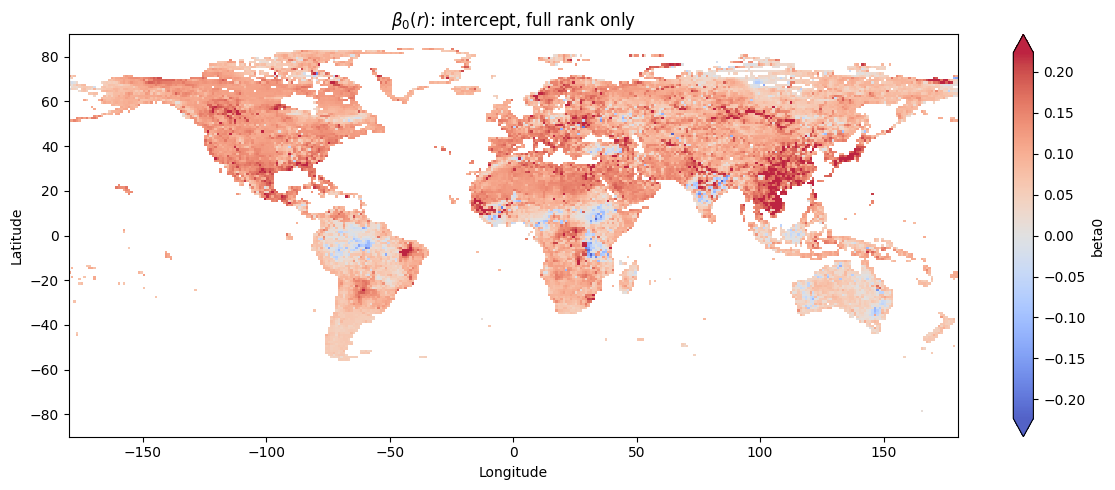

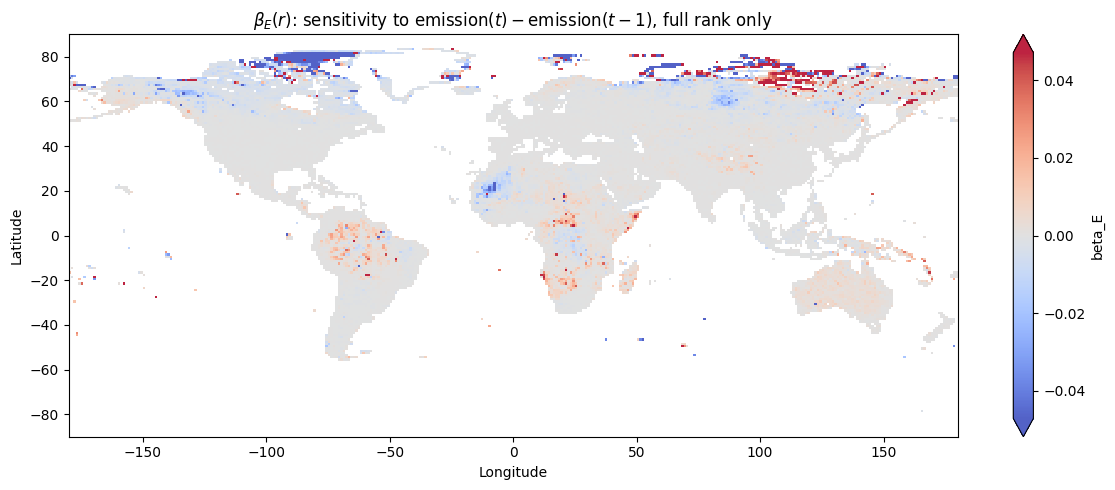

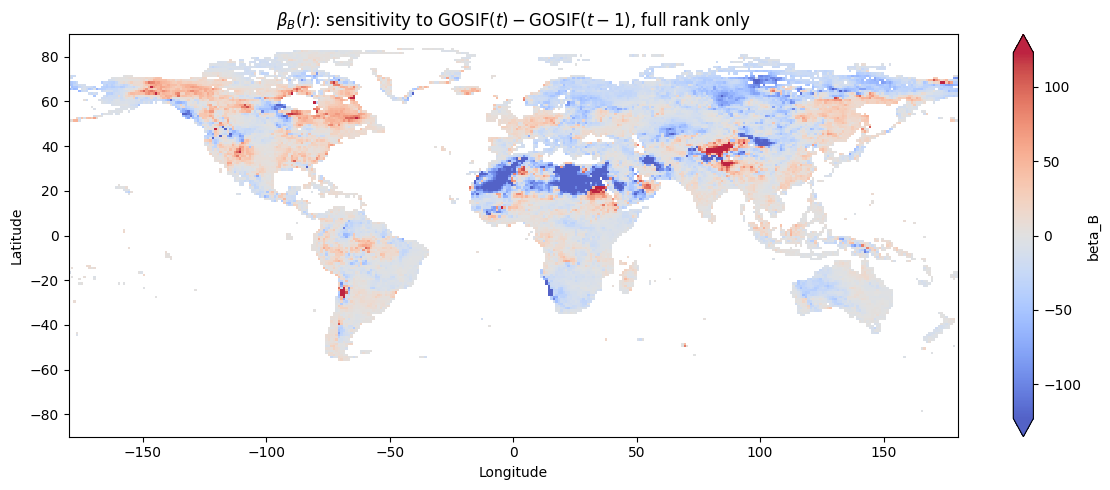

In [11]:
full_mask = out["full_model_used"] == 1

plot_map(
    out["beta0"].where(full_mask),
    title=r"$\beta_0(r)$: intercept, full rank only",
    cmap="coolwarm",
    alpha=0.88,
    save_path=FIGURE_DIR / "beta0_spo_backward_delta_fullrank.png",
)

plot_map(
    out["beta_E"].where(full_mask),
    title=r"$\beta_E(r)$: sensitivity to emission$(t)-$emission$(t-1)$, full rank only",
    cmap="coolwarm",
    alpha=0.88,
    save_path=FIGURE_DIR / "betaE_spo_backward_delta_fullrank.png",
)

plot_map(
    out["beta_B"].where(full_mask),
    title=r"$\beta_B(r)$: sensitivity to GOSIF$(t)-$GOSIF$(t-1)$, full rank only",
    cmap="coolwarm",
    alpha=0.88,
    save_path=FIGURE_DIR / "betaB_spo_backward_delta_fullrank.png",
)

## 10. Model-quality maps: $R^2$ and RMSE

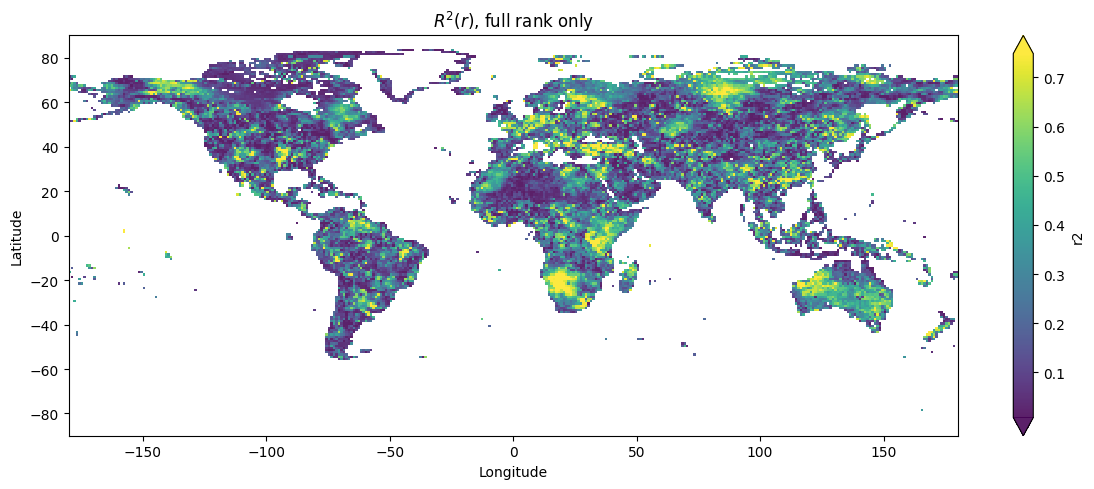

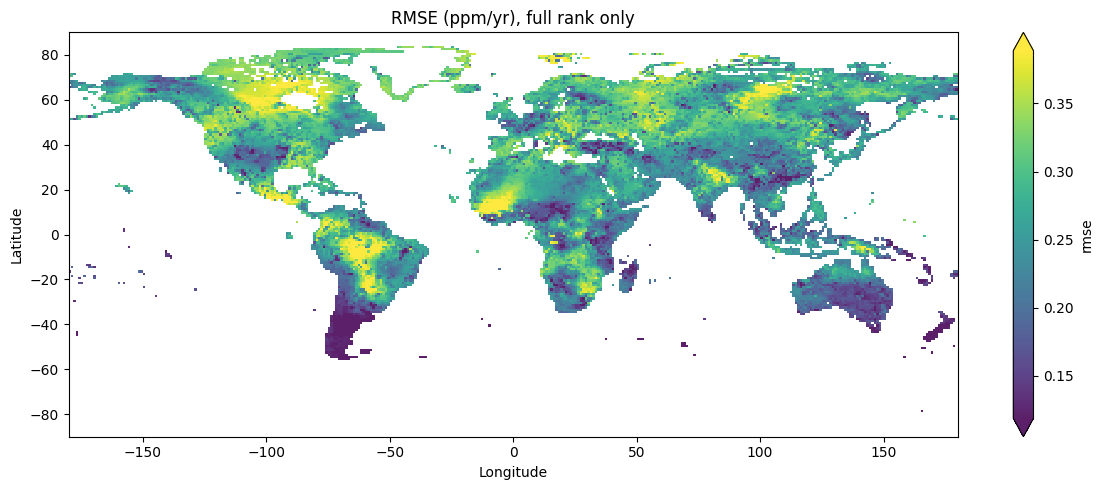

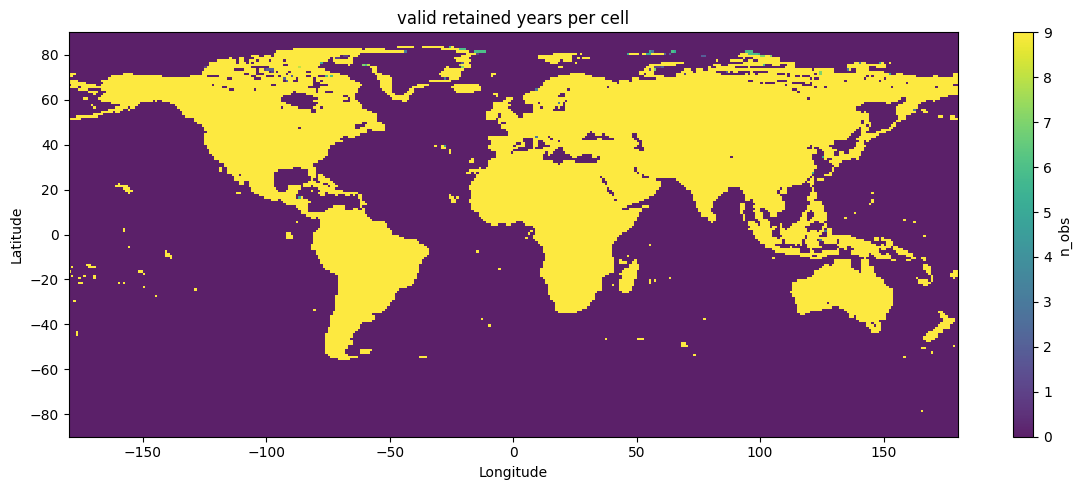

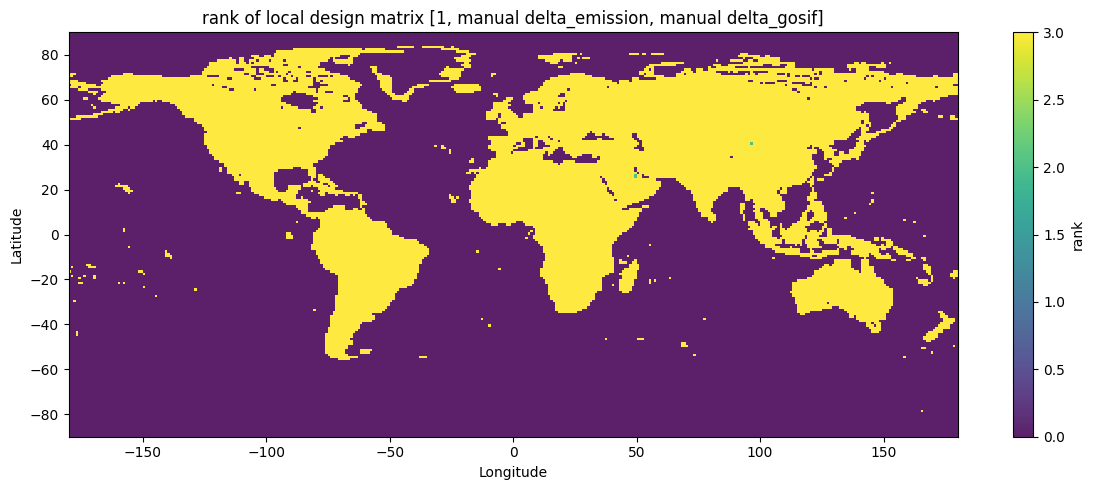

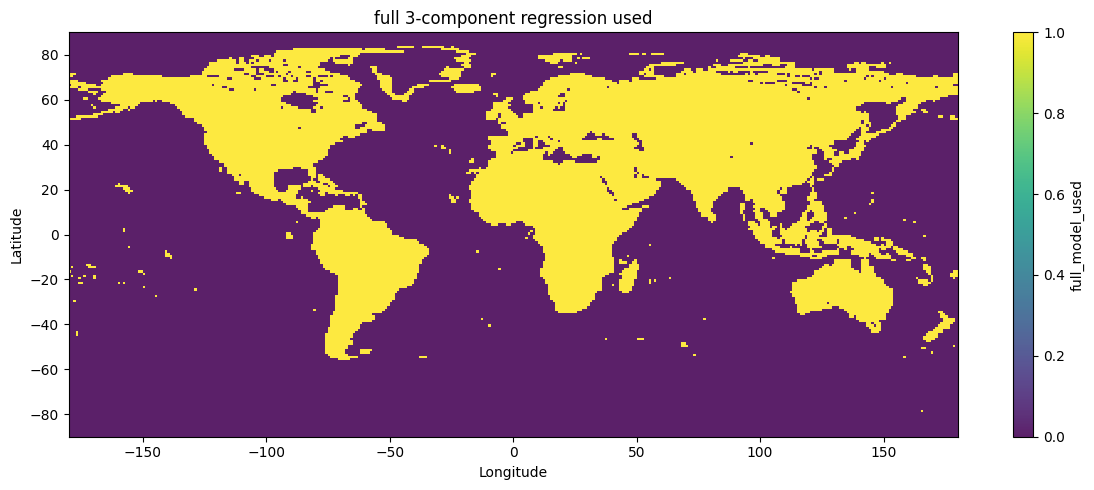

In [12]:
full_mask = out["full_model_used"] == 1

plot_map(
    out["r2"].where(full_mask),
    title=r"$R^2(r)$, full rank only",
    cmap="viridis",
    alpha=0.88,
    save_path=FIGURE_DIR / "r2_spo_backward_delta_fullrank.png",
)

plot_map(
    out["rmse"].where(full_mask),
    title="RMSE (ppm/yr), full rank only",
    cmap="viridis",
    alpha=0.88,
    save_path=FIGURE_DIR / "rmse_spo_backward_delta_fullrank.png",
)

plot_map(
    out["n_obs"],
    title="valid retained years per cell",
    cmap="viridis",
    robust=False,
    alpha=0.88,
    save_path=FIGURE_DIR / "nobs_spo_backward_delta_fullrank.png",
)

plot_map(
    out["rank"],
    title="rank of local design matrix [1, manual delta_emission, manual delta_gosif]",
    cmap="viridis",
    robust=False,
    alpha=0.88,
    save_path=FIGURE_DIR / "rank_spo_backward_delta_fullrank.png",
)

plot_map(
    out["full_model_used"],
    title="full 3-component regression used",
    cmap="viridis",
    robust=False,
    alpha=0.88,
    save_path=FIGURE_DIR / "full_model_used_spo_backward_delta_fullrank.png",
)

## 11. Global summary

In [13]:
rows = {}

for v in ["beta0", "beta_E", "beta_B", "r2", "rmse"]:
    a = out[v].values
    rows[v] = {
        "finite_fraction": np.isfinite(a).mean(),
        "mean": np.nanmean(a),
        "median": np.nanmedian(a),
        "q05": np.nanquantile(a, 0.05),
        "q95": np.nanquantile(a, 0.95),
    }

summary = pd.DataFrame(rows).T
display(summary)

print("Full-model cells:", int((out["full_model_used"] == 1).sum()), "/", out["full_model_used"].size)
print("Rank-3 cells:", int((out["rank"] == 3).sum()), "/", out["rank"].size)

,finite_fraction,mean,median,q05,q95
beta0,0.270247,0.097145,0.098692,0.005460,0.185760
beta_E,0.270247,-8.775679,0.000012,-0.009234,0.008537
beta_B,0.270247,-7.664919,-3.533248,-65.843689,40.960146
r2,0.270247,0.258703,0.210820,0.019807,0.657437
rmse,0.270247,0.262290,0.265339,0.146757,0.364772


Full-model cells: 17512 / 64800
Rank-3 cells: 17512 / 64800


## 12. Inspect one cell in 3D: points + fitted plane

Axes are:

$$
\texttt{emission}(t)-\texttt{emission}(t-1),
$$

$$
\texttt{gosif}(t)-\texttt{gosif}(t-1),
$$

and the SPO-referenced growth-rate anomaly.

The orange surface is the local plane:

$$
\beta_0+\beta_E\,\Delta E+\beta_B\,\Delta B.
$$

C:\Users\adrig\AppData\Local\Temp\ipykernel_10796\401401589.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


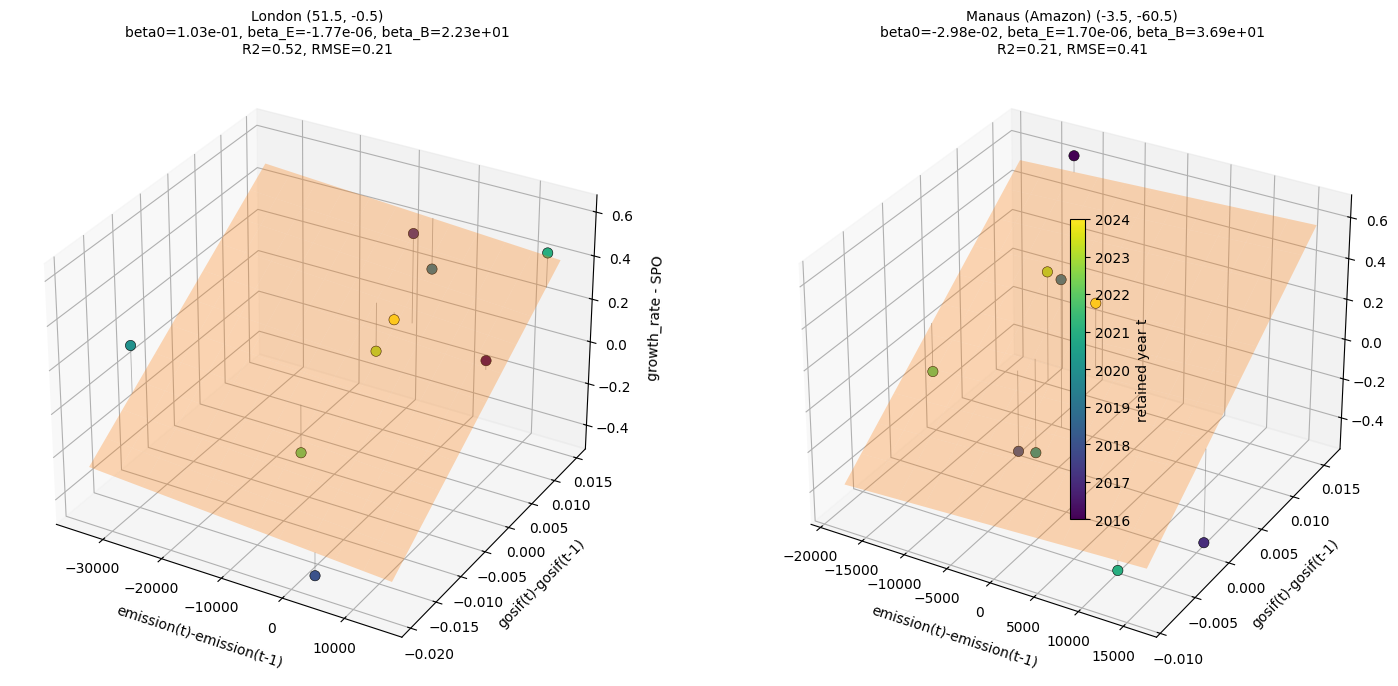

In [14]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

SITES = {
    "London": (51.5074, -0.1278),
    "Manaus (Amazon)": (-3.119, -60.022),
}

fig = plt.figure(figsize=(15, 6.5))
last_scatter = None

for i, (name, (la, lo)) in enumerate(SITES.items(), 1):
    c = out.sel(lat=la, lon=lo, method="nearest")

    E = dE.sel(lat=la, lon=lo, method="nearest").values.astype(float)
    B = dB.sel(lat=la, lon=lo, method="nearest").values.astype(float)
    z = y_anom.sel(lat=la, lon=lo, method="nearest").values.astype(float)

    valid = np.isfinite(E) & np.isfinite(B) & np.isfinite(z)

    ax = fig.add_subplot(1, len(SITES), i, projection="3d")

    nearest_lat = float(c["lat"].values)
    nearest_lon = float(c["lon"].values)

    if valid.sum() < 3 or int(c["full_model_used"].values) != 1:
        ax.set_title(
            f"{name} ({nearest_lat:.1f}, {nearest_lon:.1f})\n"
            "Full rank model not fitted here",
            fontsize=10,
        )
        ax.set_xlabel("\nemission(t)-emission(t-1)")
        ax.set_ylabel("\ngosif(t)-gosif(t-1)")
        ax.set_zlabel("\ngrowth_rate - SPO")
        continue

    E_valid = E[valid]
    B_valid = B[valid]
    z_valid = z[valid]
    years_valid = dE["time"].values[valid].astype(float)

    b0 = float(c["beta0"])
    bE = float(c["beta_E"])
    bB = float(c["beta_B"])
    r2v = float(c["r2"])
    rmsev = float(c["rmse"])

    E_min, E_max = np.nanmin(E_valid), np.nanmax(E_valid)
    B_min, B_max = np.nanmin(B_valid), np.nanmax(B_valid)

    if E_min == E_max:
        delta = 1.0 if E_min == 0 else 0.05 * abs(E_min)
        E_min -= delta
        E_max += delta

    if B_min == B_max:
        delta = 1.0 if B_min == 0 else 0.05 * abs(B_min)
        B_min -= delta
        B_max += delta

    Eg = np.linspace(E_min, E_max, 12)
    Bg = np.linspace(B_min, B_max, 12)
    EE, BB = np.meshgrid(Eg, Bg)

    ax.plot_surface(
        EE,
        BB,
        b0 + bE * EE + bB * BB,
        alpha=0.3,
        color="tab:orange",
        edgecolor="none",
        shade=False,
    )

    last_scatter = ax.scatter(
        E_valid,
        B_valid,
        z_valid,
        c=years_valid,
        cmap="viridis",
        s=55,
        edgecolor="k",
        linewidth=0.4,
        depthshade=False,
    )

    for ei, bi, zi in zip(E_valid, B_valid, z_valid):
        zi_pred = b0 + bE * ei + bB * bi
        ax.plot(
            [ei, ei],
            [bi, bi],
            [zi, zi_pred],
            color="gray",
            lw=0.6,
            alpha=0.6,
        )

    ax.set_xlabel("\nemission(t)-emission(t-1)")
    ax.set_ylabel("\ngosif(t)-gosif(t-1)")
    ax.set_zlabel("\ngrowth_rate - SPO")
    ax.set_title(
        f"{name} ({nearest_lat:.1f}, {nearest_lon:.1f})\n"
        f"beta0={b0:.2e}, beta_E={bE:.2e}, beta_B={bB:.2e}\n"
        f"R2={r2v:.2f}, RMSE={rmsev:.2f}",
        fontsize=10,
    )

if last_scatter is not None:
    fig.colorbar(last_scatter, ax=fig.axes, shrink=0.6, pad=0.08, label="retained year t")

plt.tight_layout()
plt.show()

## 13. Interpretation notes

- The target is **local growth rate minus the South Pole background**:

  \[
  Y(t,r)=\texttt{growth\_rate}(t,r)-\texttt{growth\_rate}_{SPO}(t).
  \]

- The predictors are computed manually from the raw variables:

  \[
  \Delta E(t,r)=\texttt{emission}(t,r)-\texttt{emission}(t-1,r),
  \]

  \[
  \Delta B(t,r)=\texttt{gosif}(t,r)-\texttt{gosif}(t-1,r).
  \]

- Because the notebook uses a backward difference, the first year is dropped.  
  With 2015--2024 data, the retained time labels are 2016--2024.

- The fitted model is:

  \[
  Y(t,r)
  =
  \beta_0(r)
  +
  \beta_E(r)\Delta E(t,r)
  +
  \beta_B(r)\Delta B(t,r)
  +
  \varepsilon(t,r).
  \]

- In this corrected version, the regression is solved only where `full_model_used = 1`.

- `rank = 3` means the three model components \([\beta_0,\beta_E,\beta_B]\) are identifiable.

- `n_obs` is the number of retained years where the target and both manually computed predictors are finite.

- If `REQUIRE_ALL_YEARS = True`, then the fitted grid cells must have finite target, manually computed emission change, and manually computed GOSIF change for every retained year.

- \(\beta_0(r)\) is the baseline local enhancement over the South Pole background when \(\Delta E=\Delta B=0\).

- \(\beta_E(r)>0\) means that grid cells where emissions increased relative to the previous year tend to have higher local CO₂ growth-rate enhancement relative to the South Pole background.

- \(\beta_B(r)<0\) would be consistent with increases in biospheric activity relative to the previous year being associated with lower local CO₂ growth-rate enhancement.

- The maps are masked to show only grid cells where the strict full model was actually fitted.

- The map background is drawn only if Cartopy is installed. If you want borders and land/ocean regions, install it with:

```bash
pip install cartopy
```